In [22]:
import xarray as xr
import model_reader as mr
import os
import os.path as osp
import xesmf as xe
import glob

# FGRD = '/home/d.sasaki/schultz/data/cbed_supporting_data/subhadeep/seafloor_porosity.nc'
FGRD = '/home/d.sasaki/schultz/data/cbed_supporting_data/subhadeep/globalporosity_map.grd'

ROOTDIR   = '/projects/schultz/d.sasaki/km_scale_model/mom6cobalt_25th/20240723_zstar/tasks/202603_cbed_R2py'
FPATH     = '/home/d.sasaki/scratch/mom_experiments/cbed_test_001/outputs_raw/19930101.ocean_daily.nc'
FTOPO     = '/home/d.sasaki/schultz/d.sasaki/km_scale_model/mom6cobalt_25th/mom_tools/data/grid/nwa25_interped/netcdf3/ocean_topog.nc'
FOUT = osp.join(ROOTDIR,'data/cache/porosity_neus25.nc')

def porosity_file(fout=FOUT, save=False, usecache=False):
    if usecache:
        if glob.glob(fout):
            print('Loading cached file.')
            return xr.open_dataset(fout)

    ds1   = mr.read_mom6cobalt(FPATH, FTOPO, varbs=['temp'])
    chunks = dict(x=400, y=400) if FGRD.endswith('.grd') else dict(lon=200, lat=200)
    dsgrd  = xr.open_dataset(FGRD, chunks=chunks)

    # Detect coordinate names
    has_xy  = 'x' in dsgrd.coords and 'y' in dsgrd.coords
    lon_dim = 'x'  if has_xy else 'lon'
    lat_dim = 'y'  if has_xy else 'lat'
    varb    = 'z'  if has_xy else 'porosity'
    factr   = 1 if FGRD.endswith('.nc') else 1e-2

    ds = dsgrd.sel({
        lon_dim: slice(ds1.xh.min() - 1, ds1.xh.max() + 1),
        lat_dim: slice(ds1.yh.min() - 1, ds1.yh.max() + 1),
    })

    if has_xy:
        ds = ds.rename(x='lon', y='lat')

    reg   = xe.Regridder(ds, ds1.rename(xh='lon', yh='lat'), 'bilinear')
    dsout = reg(ds)

    dsout[varb] = (dsout[varb]
                   .ffill(dim='lon').ffill(dim='lat')
                   .bfill(dim='lon').bfill(dim='lat')) * factr

    if varb != 'porosity':
        dsout = dsout.rename({varb: 'porosity'})

    dsout.load()
    dsout = dsout.rename({'lon': 'xh', 'lat':'yh'})

    if save:
        dsout.to_netcdf(fout)

    return dsout

if __name__ == '__main__':
    
    dsout = porosity_file(save=True)

/home/d.sasaki/scratch/mom_experiments/cbed_test_001/outputs_raw/19930101.ocean_daily.nc


/projects/schultz/d.sasaki/km_scale_model/mom6cobalt_25th/20240723_zstar/tasks/202603_tasks_seabed/.pixi/envs/default/lib/python3.11/site-packages/xarray/core/dataset.py:278: UserWarning: The specified chunks separate the stored chunks along dimension "y" starting at index 400. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/projects/schultz/d.sasaki/km_scale_model/mom6cobalt_25th/20240723_zstar/tasks/202603_tasks_seabed/.pixi/envs/default/lib/python3.11/site-packages/xarray/core/dataset.py:278: UserWarning: The specified chunks separate the stored chunks along dimension "x" starting at index 400. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/projects/schultz/d.sasaki/km_scale_model/mom6cobalt_25th/20240723_zstar/tasks/202603_tasks_seabed/.pixi/envs/default/lib/python3.11/site-packages/xarray/core/computation.py:454: PerformanceWarning: Regridding is increasing the number of chunks by a factor

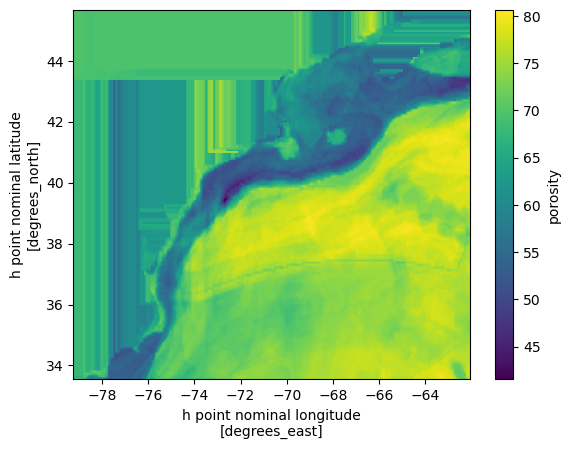

In [6]:
# ds = xr.open_dataset('/home/d.sasaki/schultz/data/cbed_supporting_data/subhadeep/seafloor_porosity.nc', chunks=dict(lon=200, lat=200))
dsout.porosity.plot()

/home/d.sasaki/scratch/mom_experiments/cbed_test_001/outputs_raw/19930101.ocean_daily.nc


/projects/schultz/d.sasaki/km_scale_model/mom6cobalt_25th/20240723_zstar/tasks/202603_tasks_seabed/.pixi/envs/default/lib/python3.11/site-packages/xarray/core/dataset.py:278: UserWarning: The specified chunks separate the stored chunks along dimension "y" starting at index 400. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/projects/schultz/d.sasaki/km_scale_model/mom6cobalt_25th/20240723_zstar/tasks/202603_tasks_seabed/.pixi/envs/default/lib/python3.11/site-packages/xarray/core/dataset.py:278: UserWarning: The specified chunks separate the stored chunks along dimension "x" starting at index 400. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/projects/schultz/d.sasaki/km_scale_model/mom6cobalt_25th/20240723_zstar/tasks/202603_tasks_seabed/.pixi/envs/default/lib/python3.11/site-packages/xarray/core/computation.py:454: PerformanceWarning: Regridding is increasing the number of chunks by a factor

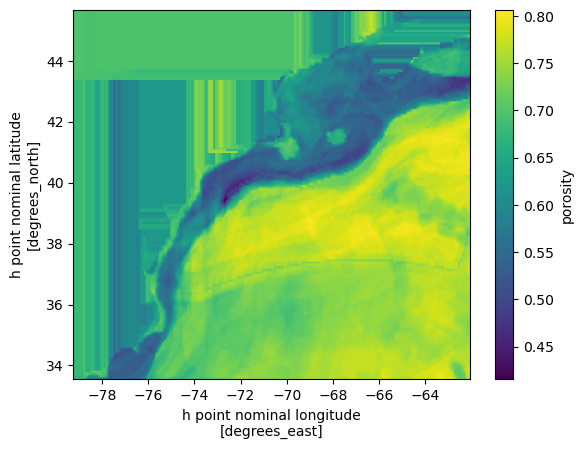

In [17]:
dsout['porosity'].plot()